In [2]:
# Install the same versions used in the project environment
# to keep the analysis reproducible.
!pip install -q \
    "pandas==2.2.3" \
    "scanpy==1.11.5" \
    "anndata==0.12.19" \
    "gseapy==1.3.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 99.1 MB/s eta 0:00:00


In [3]:
# Import Scanpy for single-cell RNA-seq analysis
import scanpy as sc

# Import AnnData for handling .h5ad files
import anndata as ad

# Import NumPy for numerical operations
import numpy as np

# Import pandas for handling metadata and tables
import pandas as pd

# Import Matplotlib for visualization
import matplotlib.pyplot as plt


# Configure Scanpy output
sc.settings.verbosity = 3

sc.settings.set_figure_params(
    dpi=120,
    facecolor="white",
    frameon=False
)


# Record the software versions used for this analysis
print("Scanpy:", sc.__version__)
print("AnnData:", ad.__version__)
print("Pandas:", pd.__version__)

Scanpy: 1.11.5
AnnData: 0.12.19
Pandas: 2.2.3


/tmp/ipykernel_3712/2967680814.py:28: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy:", sc.__version__)
/tmp/ipykernel_3712/2967680814.py:29: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print("AnnData:", ad.__version__)


In [4]:
# Mount Google Drive so the processed .h5ad files
# can be accessed from persistent storage.
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
# Load the dataset produced at the end of Step 8.3.
# This should contain the 2,500 HVGs after regression and scaling.
adata = sc.read_h5ad(
    "/content/drive/MyDrive/sc-project3-IFN-I/normalized_hvg_regressed_scaled.h5ad"
)

print(adata)
print(f"Cells: {adata.n_obs:,}")
print(f"Genes: {adata.n_vars:,}")

AnnData object with n_obs × n_vars = 94513 × 2500
    obs: 'sample', 'donor_type', 'sample_batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'hvg', 'log1p'
    layers: 'counts'
Cells: 94,513
Genes: 2,500


In [6]:
# Perform Principal Component Analysis (PCA).
#
# PCA reduces the 2,500-dimensional gene-expression space
# into a smaller number of dimensions (principal components)
# while retaining as much variation in the data as possible.
#
# n_comps=50:
# Calculate the first 50 principal components.
#
# svd_solver="arpack":
# Use the ARPACK solver, which is suitable for calculating
# a limited number of components from a large dataset.
#
# random_state=537:
# Set a fixed random seed so that the PCA result is reproducible.

sc.tl.pca(
    adata,
    n_comps=50,
    svd_solver="arpack",
    random_state=537
)

computing PCA
    with n_comps=50
    finished (0:00:26)


In [9]:
# Check the dimensions of the PCA representation.
#
# Each cell now has 50 PCA coordinates instead of
# 2,500 individual gene-expression values.

print("PCA shape:", adata.obsm["X_pca"].shape)

PCA shape: (94513, 50)


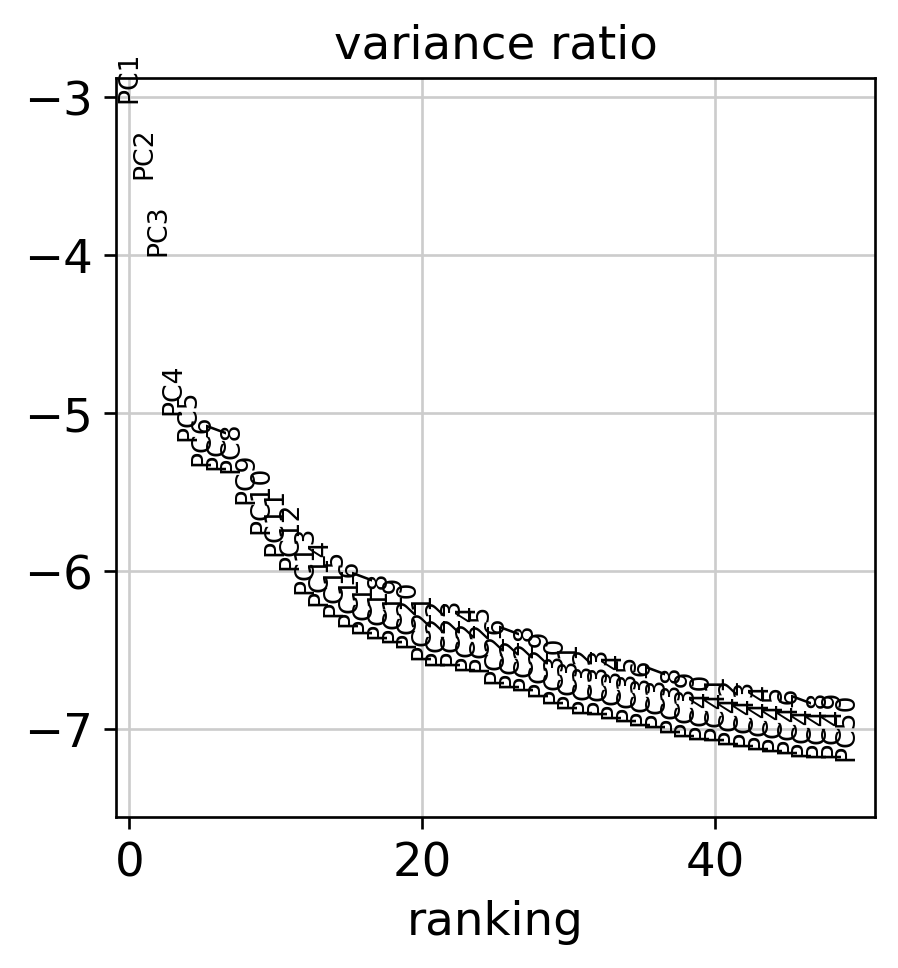

In [10]:
# Plot the proportion of total variance explained by each
# principal component.
#
# This helps assess how much information is captured by
# each PC and helps guide the choice of how many PCs
# should be used in downstream neighborhood analysis.

sc.pl.pca_variance_ratio(
    adata,
    n_pcs=50,
    log=True
)

In [11]:
# Construct a cell-to-cell neighborhood graph using
# the first 30 principal components.
#
# n_neighbors=20:
# Each cell is connected to its 20 nearest neighbors.
#
# n_pcs=30:
# The first 30 PCs are used to calculate cell similarity.

sc.pp.neighbors(
    adata,
    n_neighbors=20,
    n_pcs=30
)

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:42)


In [12]:
# Compute a UMAP embedding from the neighborhood graph.
#
# UMAP provides a 2-dimensional visualization of the
# relationships between cells while preserving local
# neighborhood structure as much as possible.

sc.tl.umap(adata)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:48)


In [14]:
# Install the graph libraries required for Leiden clustering
!pip install -q igraph leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 61.3 MB/s eta 0:00:00


In [15]:
# Perform Leiden clustering using the neighborhood graph.
#
# resolution=1.0 controls the granularity of clustering.
# Higher resolution generally produces more clusters,
# while lower resolution produces fewer clusters.
#
# key_added stores the clustering result under a
# descriptive column name in adata.obs.

sc.tl.leiden(
    adata,
    resolution=1.0,
    key_added="leiden_res_1.0"
)


# Count the number of clusters identified
n_clusters = len(
    adata.obs["leiden_res_1.0"].unique()
)

print(f"Identified {n_clusters} clusters.")

running Leiden clustering


/tmp/ipykernel_3712/1882070877.py:10: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


    finished: found 32 clusters and added
    'leiden_res_1.0', the cluster labels (adata.obs, categorical) (0:05:41)
Identified 32 clusters.


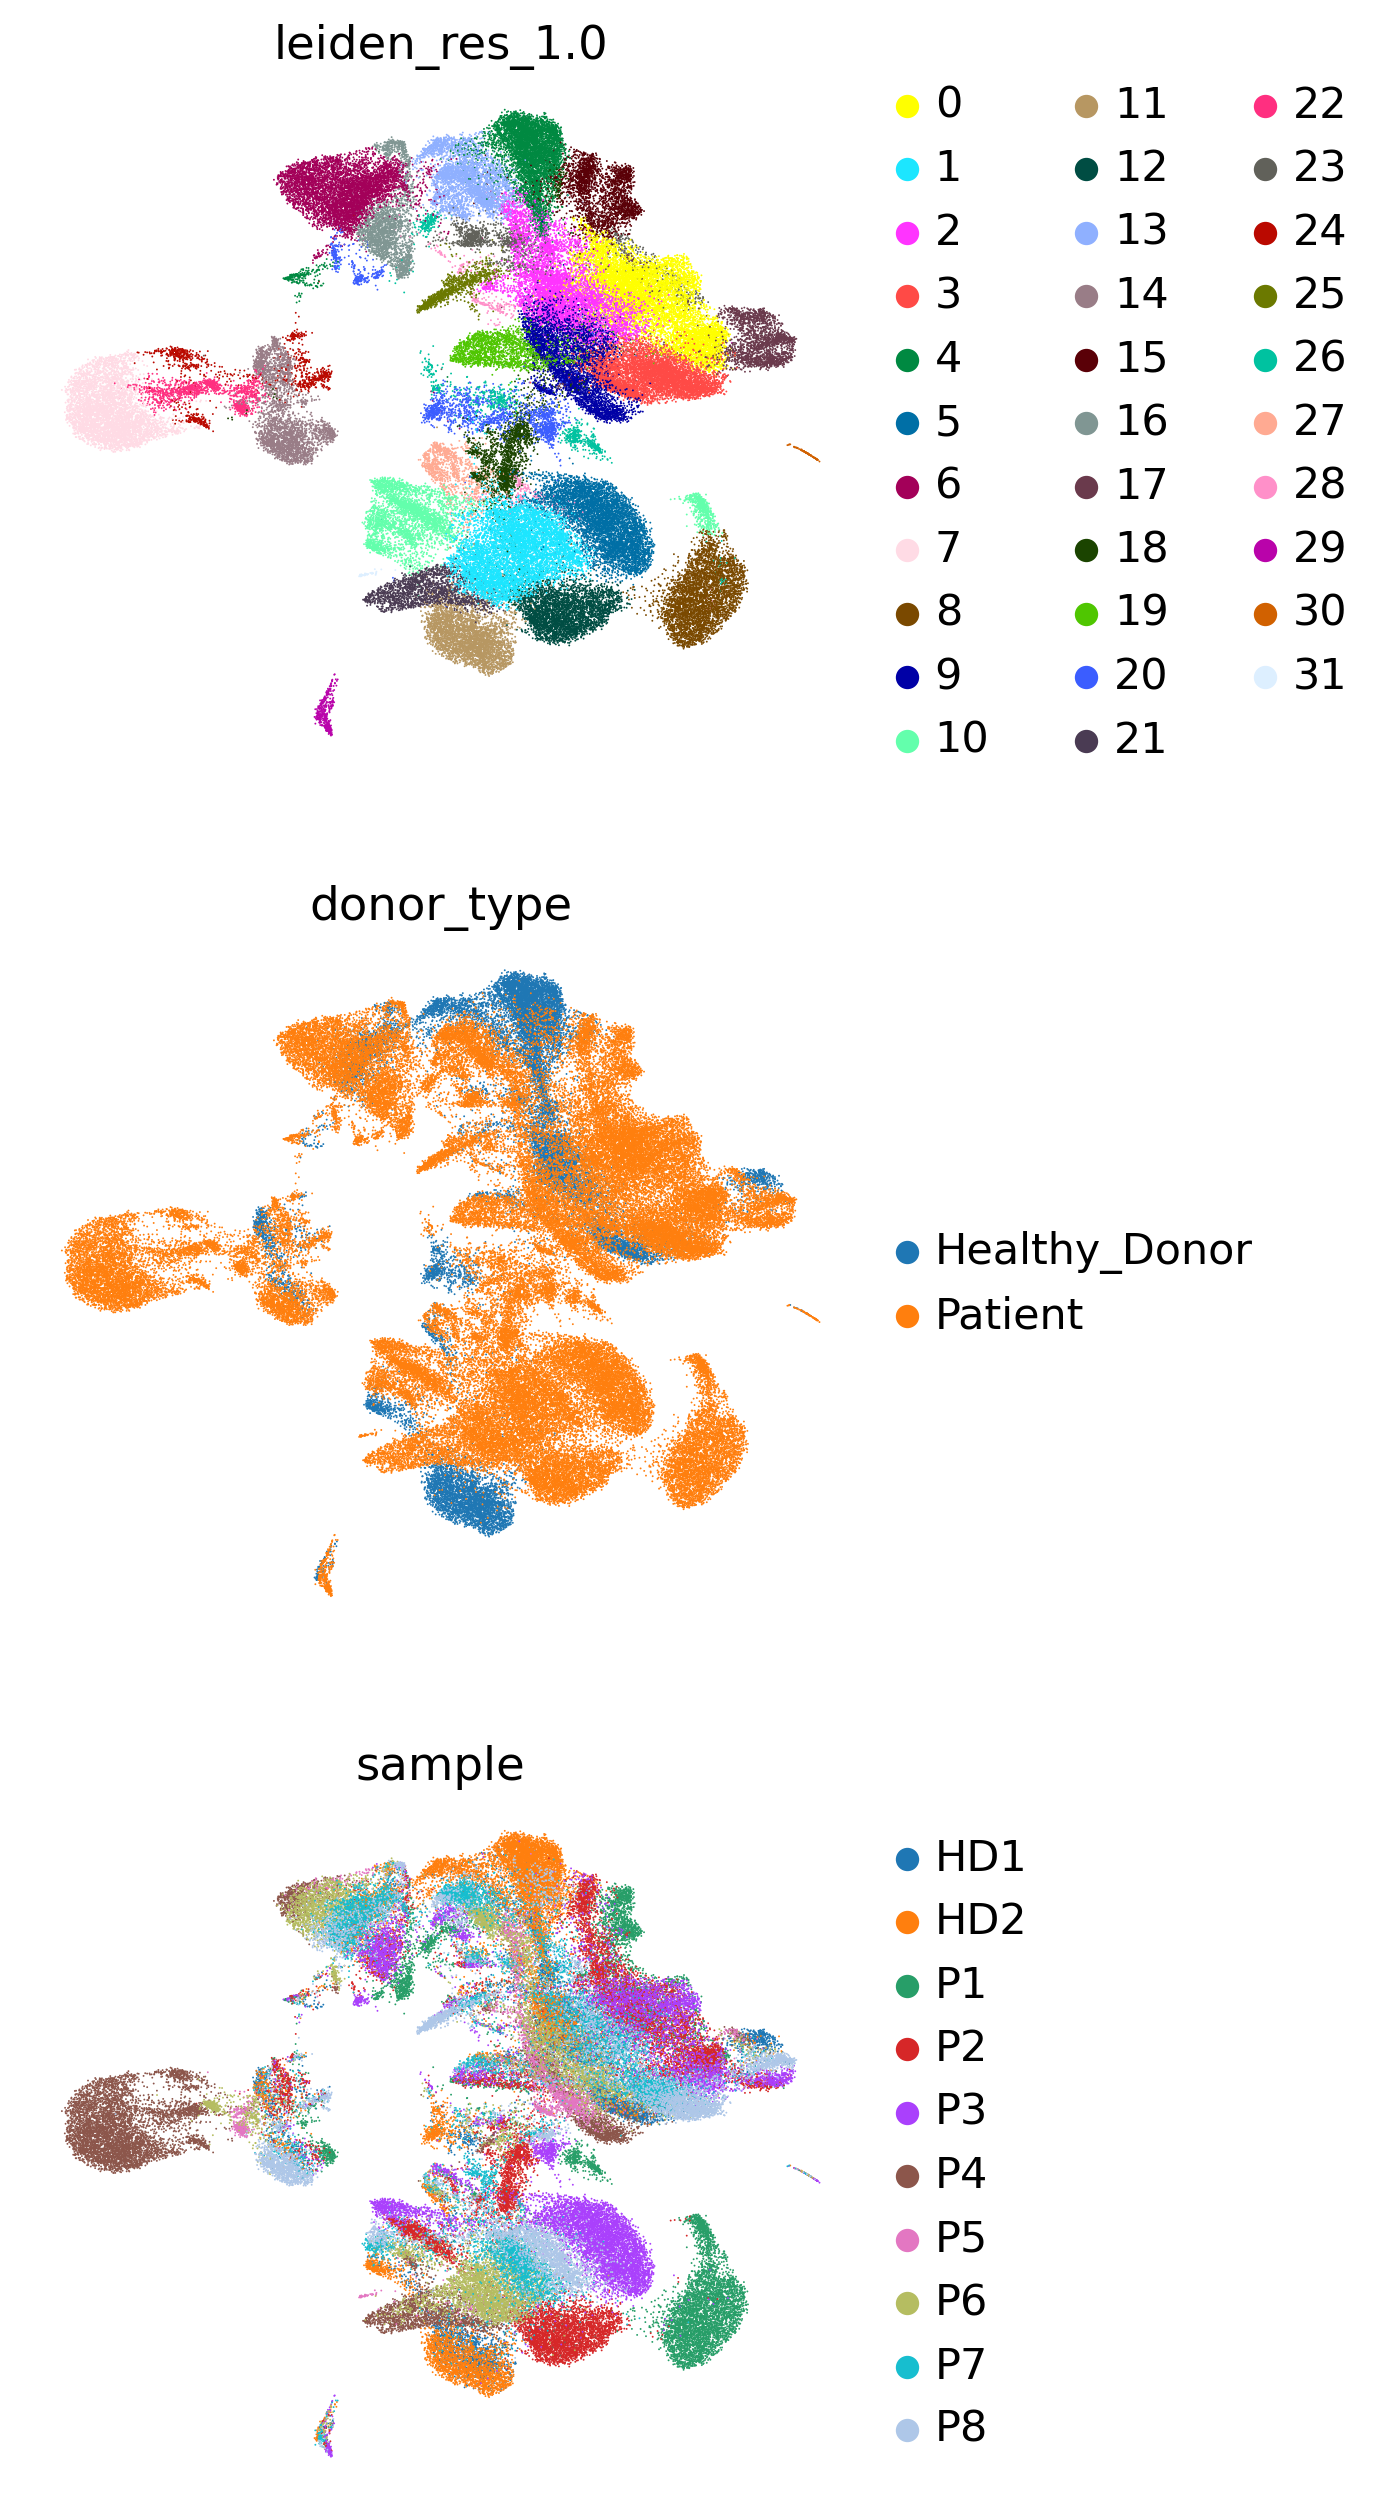

In [17]:
# Visualize the UMAP colored by:
# - Leiden cluster assignment
# - donor type
# - sample
#
# Comparing these plots helps assess whether clusters
# correspond primarily to biological differences or
# potentially to sample/donor-specific effects.

sc.pl.umap(
    adata,
    color=[
        "leiden_res_1.0",
        "donor_type",
        "sample"
    ],
    ncols=1
)

In [18]:
# Save the dataset after PCA, neighborhood graph,
# UMAP, and Leiden clustering.
#
# This file will contain the results needed for the
# next stage of analysis.

adata.write_h5ad(
    "/content/drive/MyDrive/sc-project3-IFN-I/clustering_res1.0.h5ad"
)

print("Step 8.4 dataset saved successfully.")

Step 8.4 dataset saved successfully.


In [19]:
# Define canonical marker genes for each major immune lineage.
#
# These markers will be used to determine which cell populations
# are represented by the Leiden clusters.

lineage_dict = {
    "CD4_T": ["CD3D", "CD4", "IL7R", "CCR7"],
    "CD8_T": ["CD3D", "CD8A", "CD8B", "GZMB"],
    "NK": ["NKG7", "GNLY", "NCAM1"],
    "B_cells": ["MS4A1", "CD19", "CD79A"],
    "Monocytes": ["CD14", "FCGR3A", "LYZ"],
    "DC": ["FCER1A", "CST3"]
}

In [20]:
# Check which marker genes are present in the current dataset.
# Markers that are not among the 2,500 HVGs cannot be plotted
# directly from adata.X.

available_markers = {
    lineage: [
        gene for gene in markers
        if gene in adata.var_names
    ]
    for lineage, markers in lineage_dict.items()
}

for lineage, markers in available_markers.items():
    print(f"{lineage}: {markers}")

CD4_T: ['IL7R', 'CCR7']
CD8_T: ['CD8A', 'CD8B', 'GZMB']
NK: ['NKG7', 'GNLY', 'NCAM1']
B_cells: ['MS4A1', 'CD79A']
Monocytes: ['FCGR3A', 'LYZ']
DC: ['FCER1A', 'CST3']


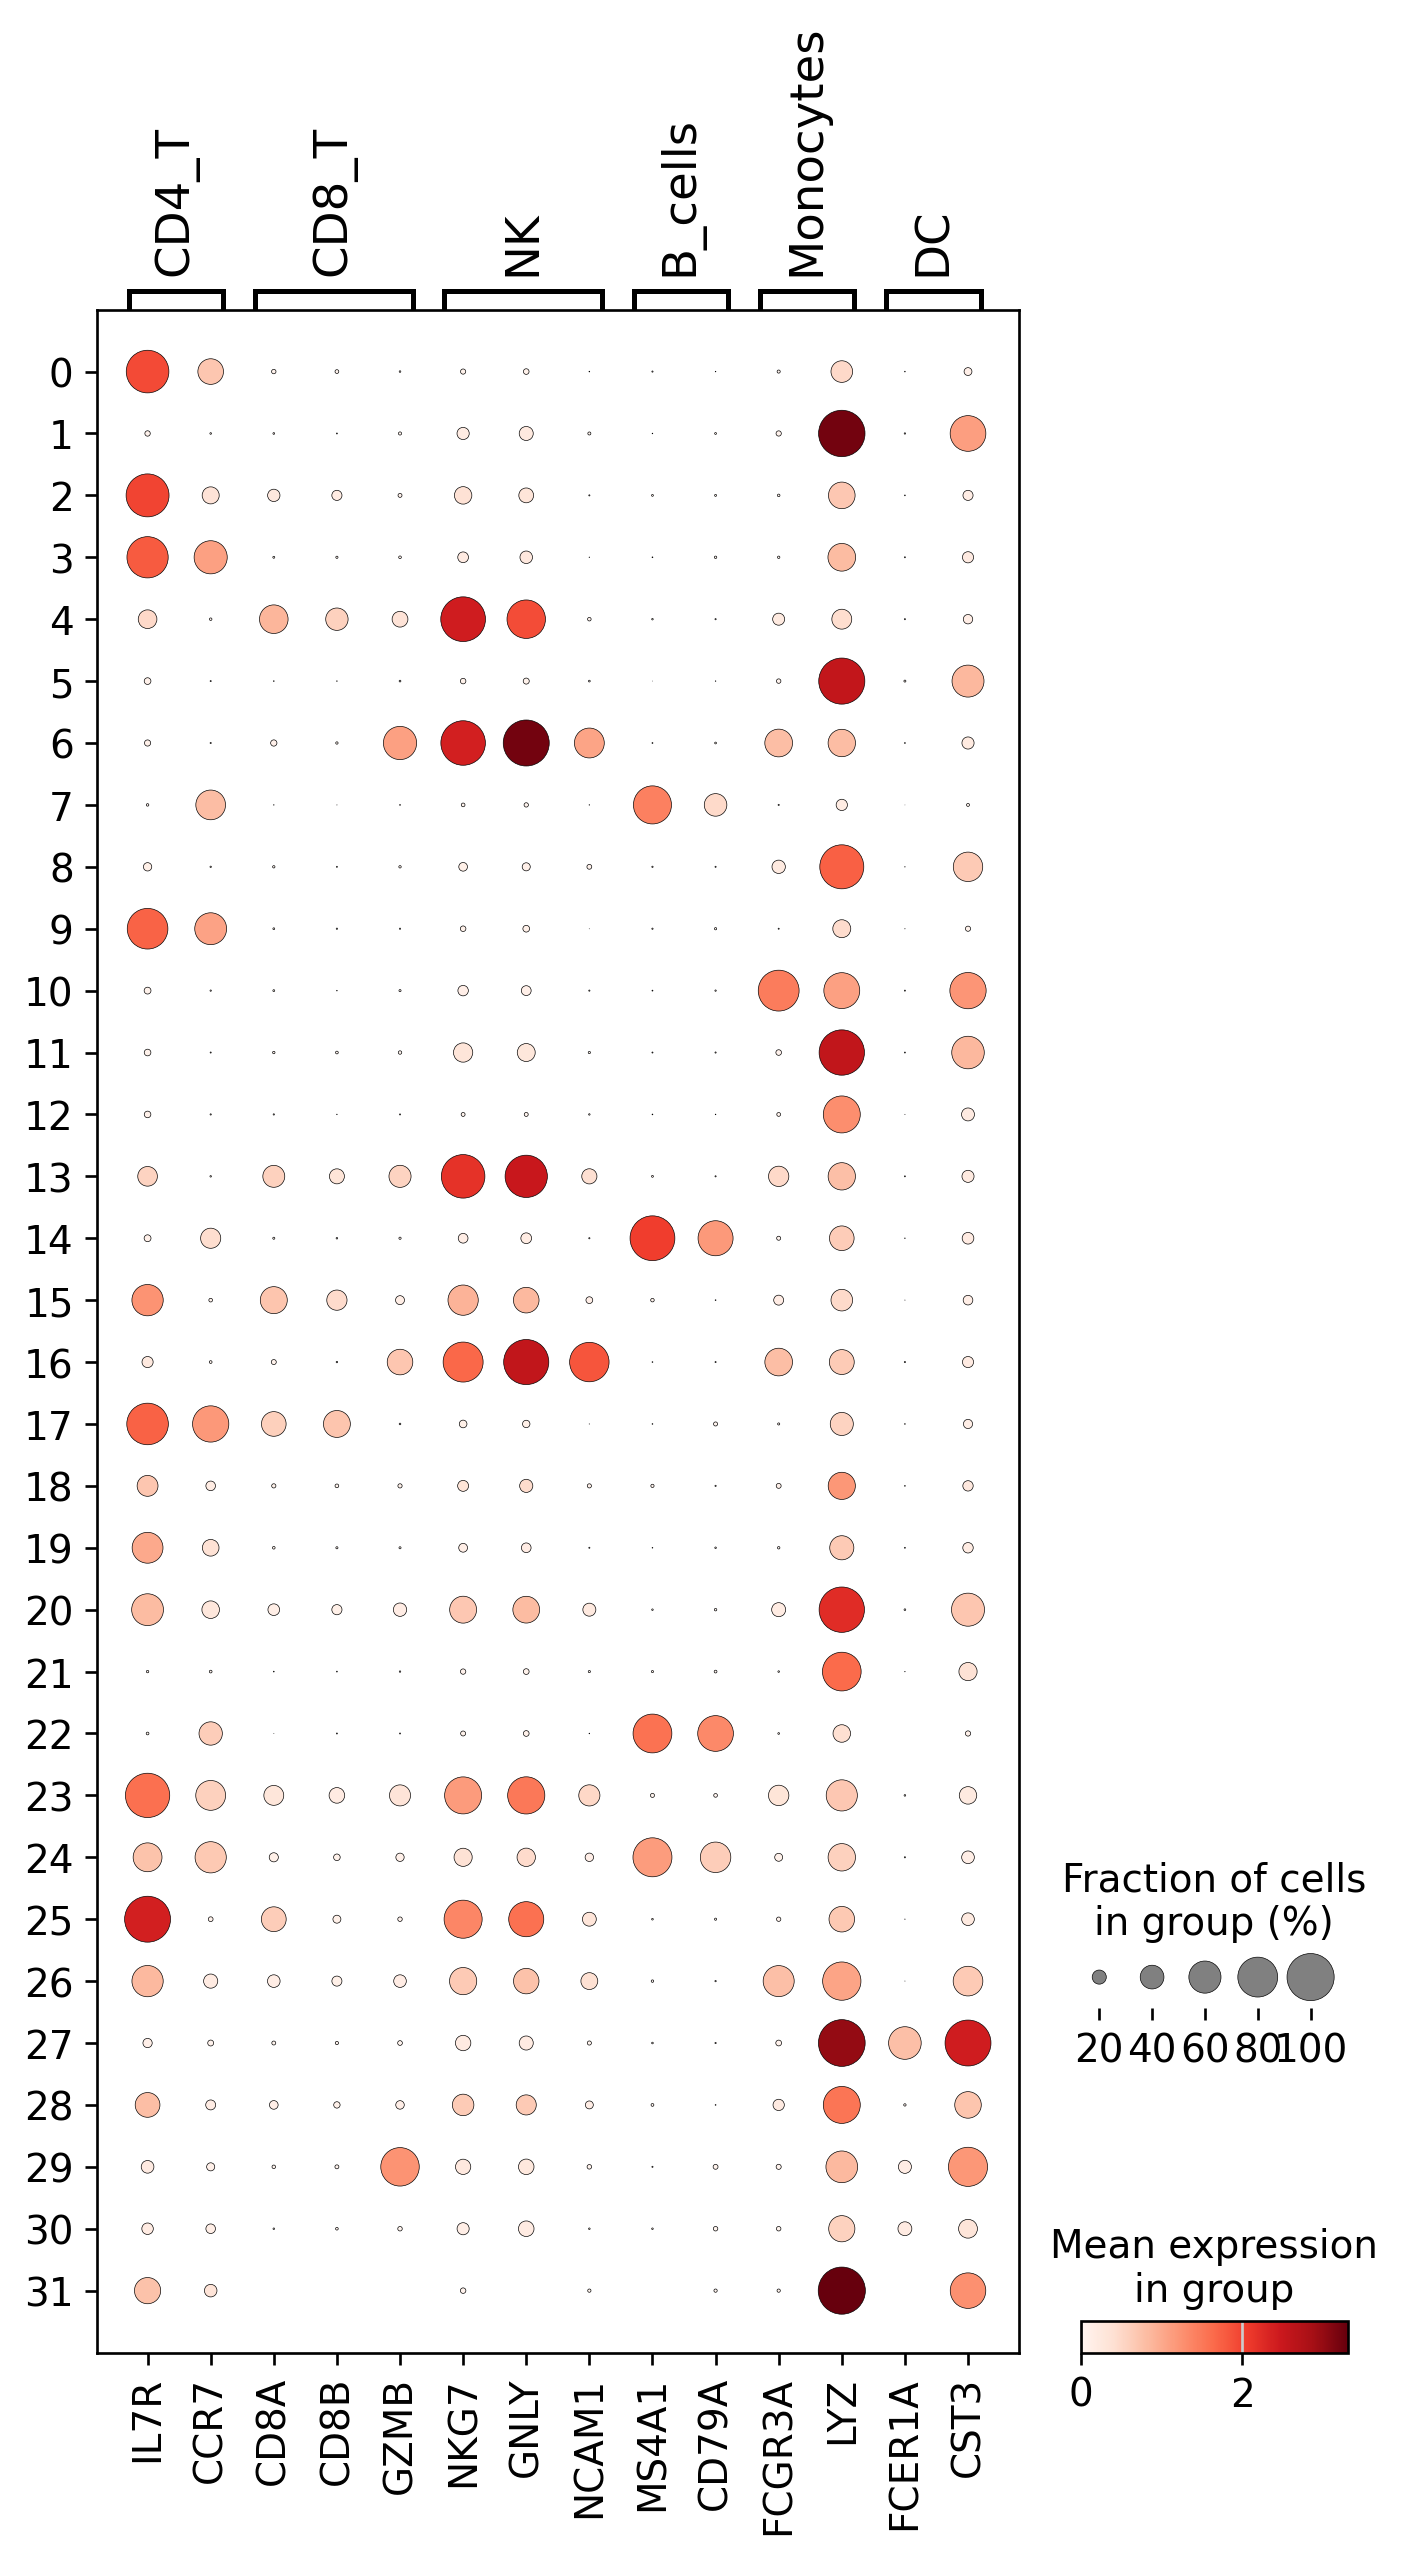

In [21]:
# Visualize marker-gene expression across Leiden clusters.
#
# Dot size represents the fraction of cells expressing the gene,
# while dot color represents the average expression level.
#
# This allows us to compare canonical lineage markers across
# the different clusters.

sc.pl.dotplot(
    adata,
    var_names=available_markers,
    groupby="leiden_res_1.0"
)

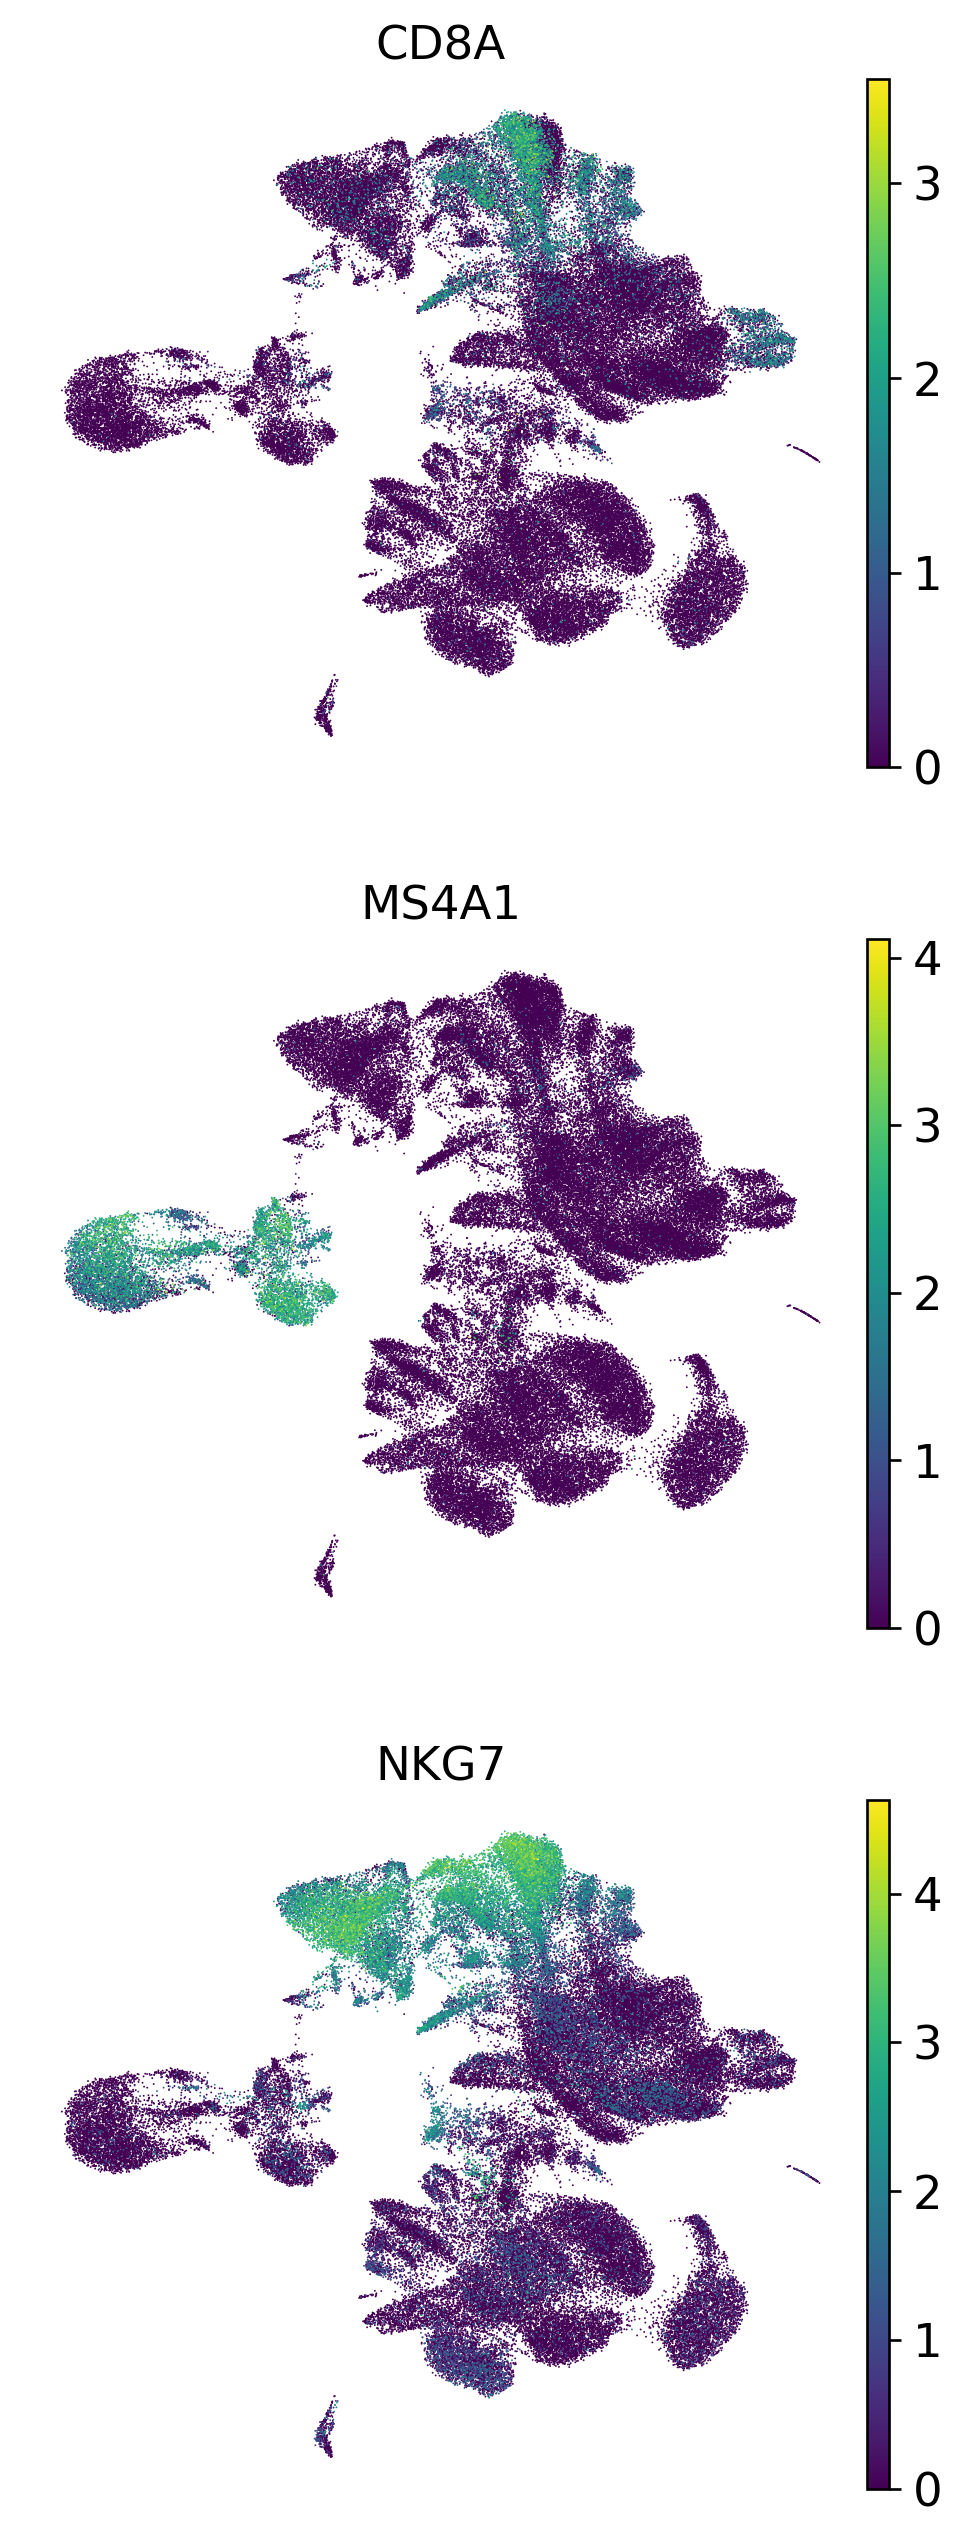

In [23]:
# Select commonly informative immune markers that are available
# in the current 2,500-gene dataset.

umap_markers = [
    gene for gene in [
        "CD3D",
        "CD4",
        "CD8A",
        "MS4A1",
        "CD14",
        "NKG7"
    ]
    if gene in adata.var_names
]

# Plot the expression of each marker across the UMAP embedding.
sc.pl.umap(
    adata,
    color=umap_markers,
    ncols=1
)

In [24]:
# Check the canonical markers against the full gene set
# retained in adata.raw.

available_markers_raw = {
    lineage: [
        gene for gene in markers
        if gene in adata.raw.var_names
    ]
    for lineage, markers in lineage_dict.items()
}

for lineage, markers in available_markers_raw.items():
    print(f"{lineage}: {markers}")

CD4_T: ['CD3D', 'CD4', 'IL7R', 'CCR7']
CD8_T: ['CD3D', 'CD8A', 'CD8B', 'GZMB']
NK: ['NKG7', 'GNLY', 'NCAM1']
B_cells: ['MS4A1', 'CD19', 'CD79A']
Monocytes: ['CD14', 'FCGR3A', 'LYZ']
DC: ['FCER1A', 'CST3']


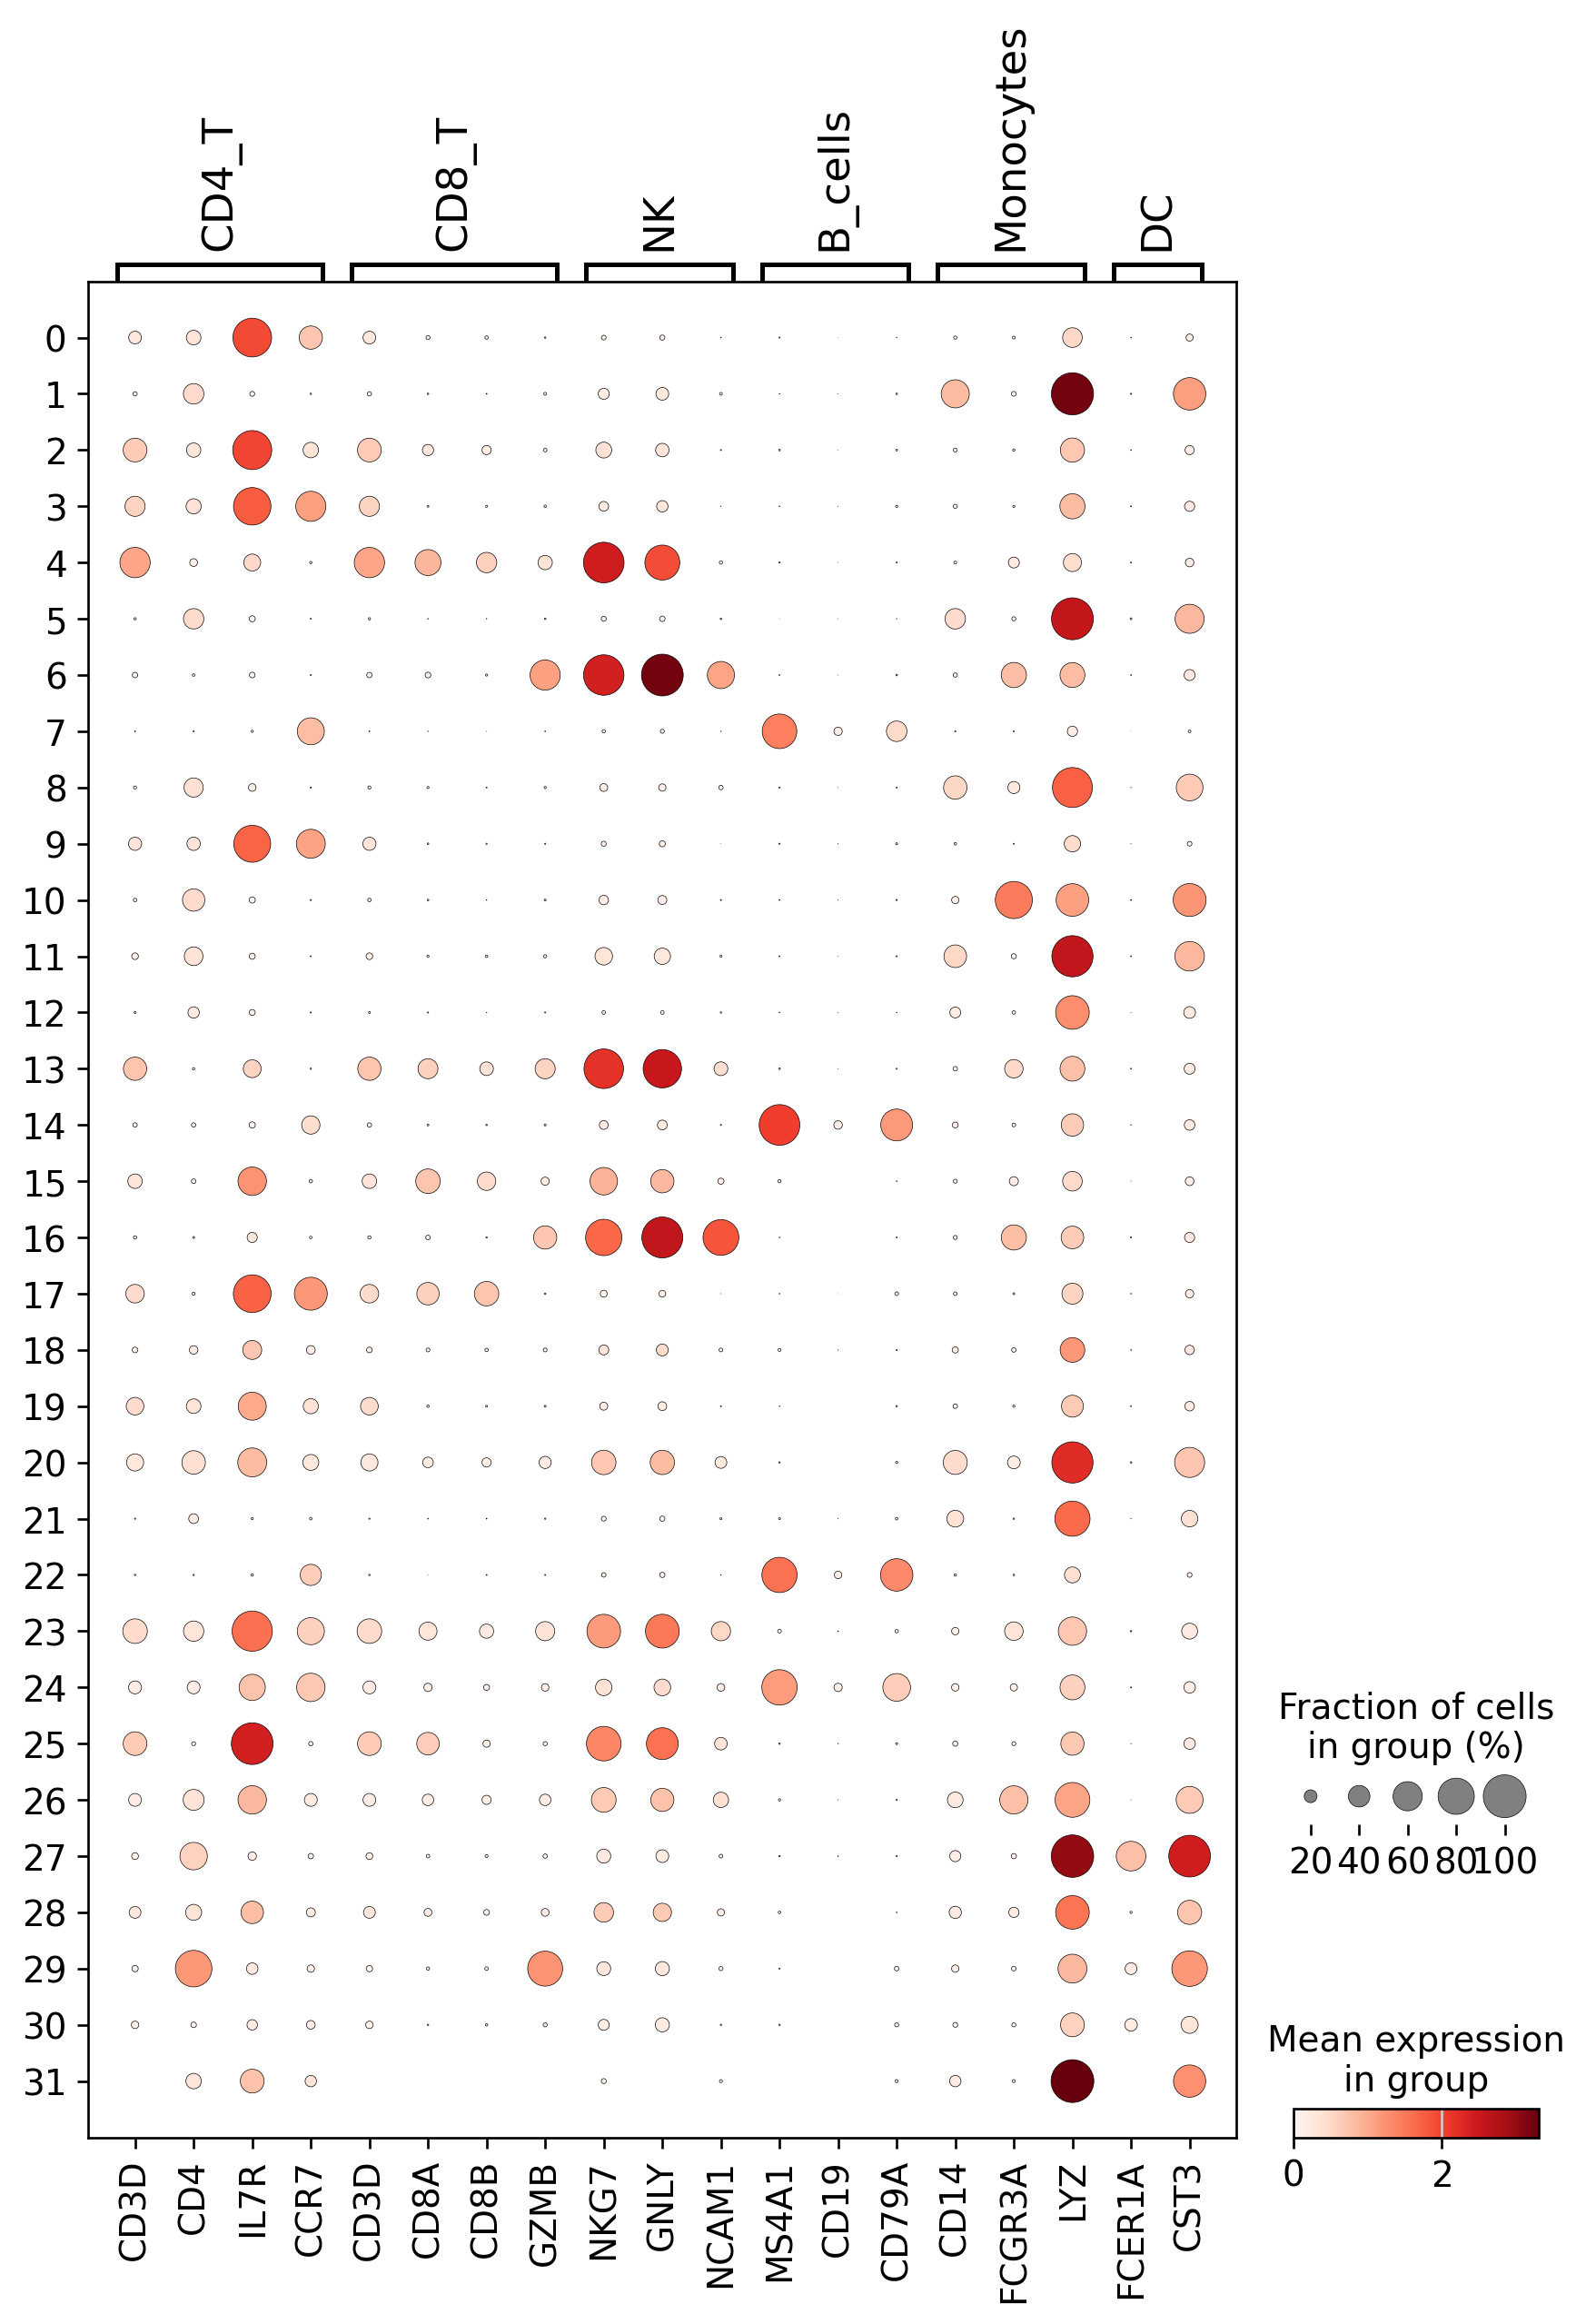

In [25]:
# Plot canonical immune-lineage markers across Leiden clusters.
#
# adata.raw is used so that marker genes that were not selected
# as HVGs can still be examined.

sc.pl.dotplot(
    adata,
    var_names=available_markers_raw,
    groupby="leiden_res_1.0",
    use_raw=True
)

In [26]:
# Visualize canonical immune markers on the UMAP.
# use_raw=True allows markers outside the 2,500 HVGs
# to be visualized from the full normalized expression matrix.

umap_markers = [
    "CD3D",
    "CD4",
    "CD8A",
    "MS4A1",
    "CD14",
    "NKG7"
]

sc.pl.umap(
    adata,
    color=umap_markers,
    use_raw=True,
    ncols=3
)

Output hidden; open in https://colab.research.google.com to view.